# Customer Churn Prediction using ANN

This project analyzes customer churn and builds Artificial Neural Network (ANN) models to predict whether a customer is likely to leave.

### Project workflow
1. Import libraries
2. Load and inspect the dataset
3. Exploratory Data Analysis (EDA)
4. Data preprocessing
5. Train/test split
6. Build baseline and improved ANN models
7. Evaluate models using classification metrics
8. Compare model performance
9. Summarize findings

> **Dataset:** Telco customer churn data. The target variable is 'Churn'


## 1. Import Libraries

In [6]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Load the Dataset

In [7]:
df = pd.read_csv("/content/customer_churn.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# Basic dataset information
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(10))


Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Missing values:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## 3. Exploratory Data Analysis

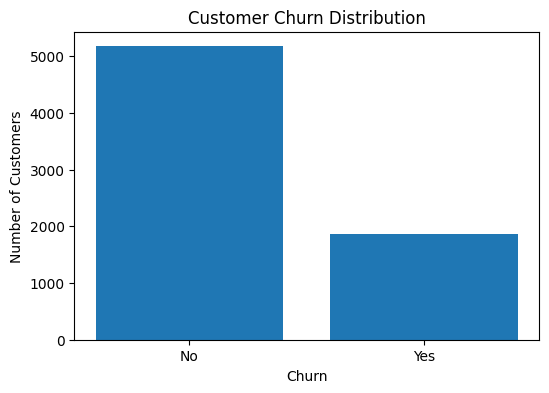

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.46
Yes    26.54
Name: count, dtype: float64


In [9]:
# Churn distribution
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

print("Churn distribution:")
print(churn_counts)
print("\nChurn percentage:")
print((churn_counts / len(df) * 100).round(2))


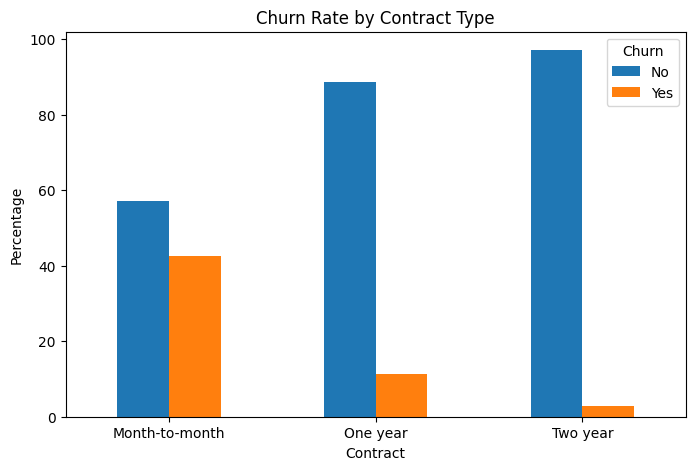

In [10]:
# Churn rate by contract type
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()


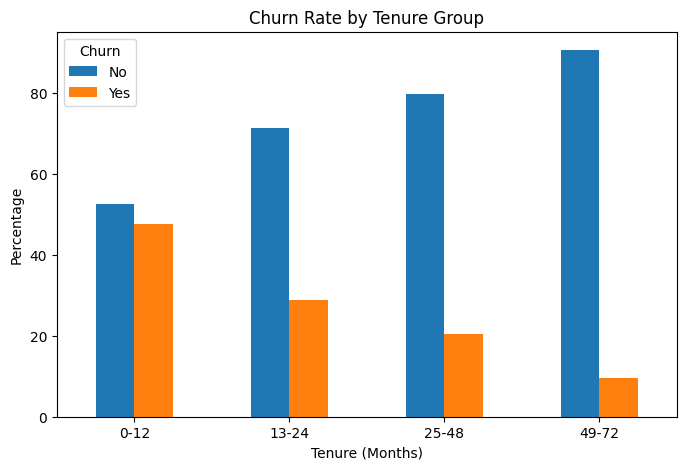

In [11]:
# Churn rate by tenure group
tenure_bins = [-1, 12, 24, 48, 72]
tenure_labels = ["0-12", "13-24", "25-48", "49-72"]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels
)

tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure (Months)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()


In [12]:
# Remove the temporary EDA-only column
df.drop(columns=["TenureGroup"], inplace=True)


## 4. Data Preprocessing

`TotalCharges` is stored as text in the raw dataset because some records contain blank values. It is converted to numeric, with invalid/blank values becoming missing values.

`customerID` is an identifier rather than a useful predictive feature, so it is removed.

Categorical variables are one-hot encoded and numerical variables are standardized.


In [13]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove rows with missing TotalCharges
df = df.dropna(subset=["TotalCharges"]).copy()

# Remove customer identifier
df.drop(columns=["customerID"], inplace=True)

# Encode target
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print("Shape after preprocessing:", df.shape)
print("Missing values remaining:", df.isnull().sum().sum())


Shape after preprocessing: (7032, 20)
Missing values remaining: 0


## 5. Train-Test Split

In [14]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 5625
Testing samples: 1407


### Preprocessing pipeline

The preprocessing object is fitted only on the training data to avoid data leakage.

- Numerical features → StandardScaler
- Categorical features → OneHotEncoder


In [15]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


Processed training shape: (5625, 45)
Processed testing shape: (1407, 45)


## 6. ANN Model 1 — Baseline

The first model is a simple feed-forward neural network using the processed customer features as a baseline.

In [16]:
baseline_model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_processed.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,017 (7.88 KB)

 Trainable params: 2,017 (7.88 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

baseline_history = baseline_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7564 - loss: 0.4953 - val_accuracy: 0.7849 - val_loss: 0.4234
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7947 - loss: 0.4288 - val_accuracy: 0.8018 - val_loss: 0.4080
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8009 - loss: 0.4200 - val_accuracy: 0.8062 - val_loss: 0.4065
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8049 - loss: 0.4157 - val_accuracy: 0.8071 - val_loss: 0.4068
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8073 - loss: 0.4130 - val_accuracy: 0.8053 - val_loss: 0.4074
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8089 - loss: 0.4108 - val_accuracy: 0.8089 - val_loss: 0.4081
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8116 - loss: 0.4086 - val_accuracy: 0.8071 - val_loss: 0.4089
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8138 - loss: 0.4069 - val_accuracy: 0.

## 7. ANN Model 2 — Dropout Regularization

Dropout randomly disables a proportion of neurons during training. It is used here as a regularization technique to reduce overfitting.

In [18]:
dropout_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_processed.shape[1],)),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(1, activation="sigmoid")
])

dropout_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dropout_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 5,057 (19.75 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
dropout_history = dropout_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7342 - loss: 0.5129 - val_accuracy: 0.7956 - val_loss: 0.4169
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7882 - loss: 0.4429 - val_accuracy: 0.8044 - val_loss: 0.4079
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7909 - loss: 0.4403 - val_accuracy: 0.8009 - val_loss: 0.4057
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7949 - loss: 0.4340 - val_accuracy: 0.8027 - val_loss: 0.4040
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8020 - loss: 0.4251 - val_accuracy: 0.8018 - val_loss: 0.4046
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7991 - loss: 0.4238 - val_accuracy: 0.8000 - val_loss: 0.4039
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8018 - loss: 0.4218 - val_accuracy: 0.8009 - val_loss: 0.4034
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8098 - loss: 0.4207 - val_accuracy: 0.

## 8. ANN Model 3 — Wider Network

The third model uses a wider network with additional hidden units to give the model more capacity to learn non-linear relationships in the customer data.

In [20]:
full_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_processed.shape[1],)),
    Dropout(0.30),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

full_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

full_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,257 (63.50 KB)

 Trainable params: 16,257 (63.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
full_history = full_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7540 - loss: 0.4889 - val_accuracy: 0.7982 - val_loss: 0.4108
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8033 - loss: 0.4310 - val_accuracy: 0.7982 - val_loss: 0.4042
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7973 - loss: 0.4302 - val_accuracy: 0.8018 - val_loss: 0.4051
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8069 - loss: 0.4216 - val_accuracy: 0.8044 - val_loss: 0.4034
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8058 - loss: 0.4211 - val_accuracy: 0.8053 - val_loss: 0.4074


## 9. Training Performance

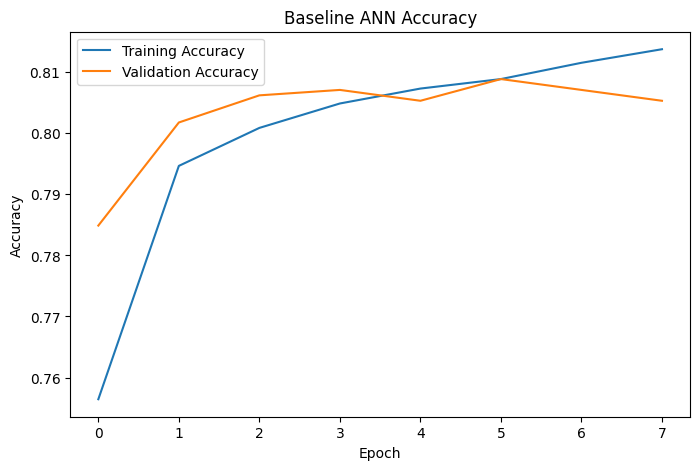

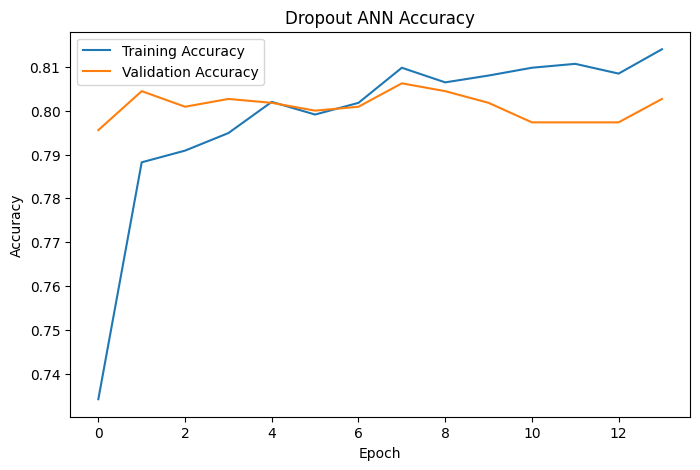

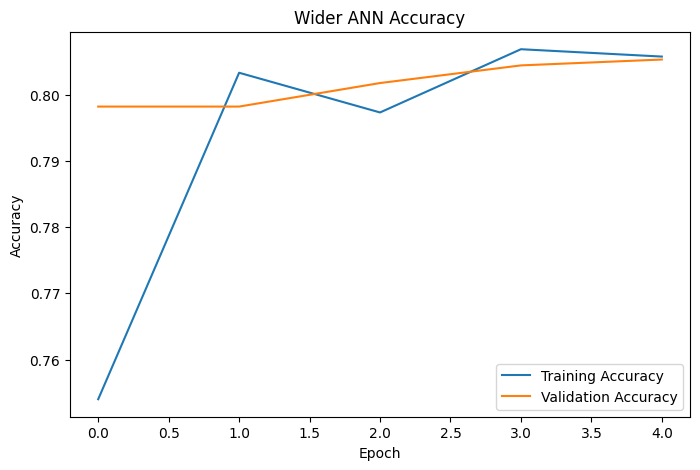

In [22]:
def plot_training_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_training_history(baseline_history, "Baseline ANN Accuracy")
plot_training_history(dropout_history, "Dropout ANN Accuracy")
plot_training_history(full_history, "Wider ANN Accuracy")


## 10. Model Evaluation

In [23]:
def evaluate_model(model, X_test, y_test, model_name):
    probabilities = model.predict(X_test, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0)
    }

    return metrics, predictions

results = []
predictions_dict = {}

for model, name in [
    (baseline_model, "Baseline ANN"),
    (dropout_model, "Dropout ANN"),
    (full_model, "Wider ANN")
]:
    metrics, predictions = evaluate_model(
        model, X_test_processed, y_test, name
    )
    results.append(metrics)
    predictions_dict[name] = predictions

results_df = pd.DataFrame(results).sort_values(
    by="F1 Score",
    ascending=False
)

results_df


,Model,Accuracy,Precision,Recall,F1 Score
2,Wider ANN,0.803127,0.653968,0.550802,0.597968
0,Baseline ANN,0.795309,0.644295,0.513369,0.571429
1,Dropout ANN,0.790334,0.644689,0.470588,0.544049


In [24]:
# Detailed classification report for the best model
best_model_name = results_df.iloc[0]["Model"]
best_predictions = predictions_dict[best_model_name]

print("Best model:", best_model_name)
print()
print(classification_report(
    y_test,
    best_predictions,
    target_names=["No Churn", "Churn"],
    zero_division=0
))


Best model: Wider ANN

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.55      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.80      0.80      0.80      1407



## 11. Confusion Matrix

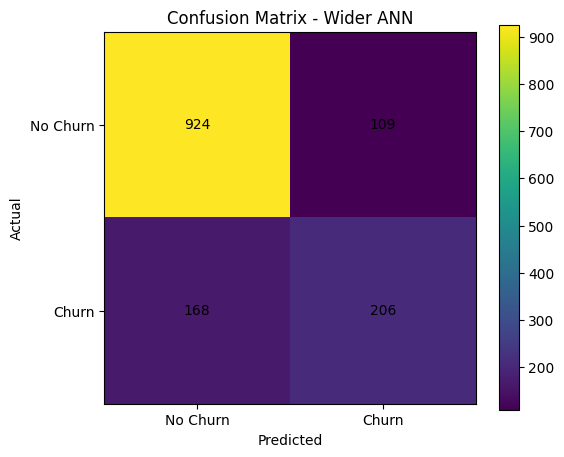

In [25]:
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


## 12. Conclusion

This project demonstrates an end-to-end customer churn prediction workflow using an Artificial Neural Network.

### Key steps
- Explored the customer churn dataset
- Cleaned and transformed `TotalCharges`
- Removed the customer identifier
- Encoded categorical variables using one-hot encoding
- Standardized numerical variables
- Split the data into training and testing sets
- Built and compared three ANN architectures
- Used dropout and early stopping as regularization techniques
- Evaluated models using accuracy, precision, recall, F1 score, and a confusion matrix

The model comparison table above can be used to identify the strongest model based on the evaluation metric most appropriate for the business objective.
